In [5]:
import OptimalBattery.simulate as sim
import torch as pt
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import OptimalBattery.plot as plot
from scipy.stats import pearsonr
from OptimalBattery.global_config import save_dir


# Start with a base U 

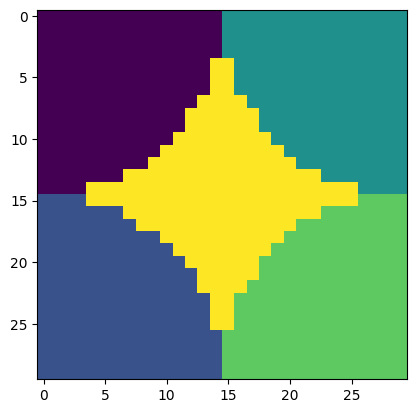

In [6]:
device = pt.device("cuda" if pt.cuda.is_available() else "cpu")

grid_height = 30
grid_width = 30

U_true_5 = sim.make_U_spatial(height=grid_height, width=grid_width, K_main= 5)
U_true_5 = pt.from_numpy(U_true_5).to(device)

labels = pt.argmax(U_true_5, axis=0)          
label_map = labels.reshape(grid_height, grid_width)           
plt.imshow(label_map.cpu().numpy())
plt.show()

# make individual Us that vary in about 2 SD in region size

In [7]:
U_individuals = sim.make_U_individuals(U_true_5,grid_width,grid_height, n_individuals=5000,
                            size_range = (120,240),seed=1,device=device)

# for i, U in enumerate(U_individuals[:10]):
#     label_map = np.argmax(U.cpu().numpy(), axis=0).reshape(grid_width, grid_height)
#     plt.imshow(label_map.T)
#     plt.title(f'Individual {i+1}')
#     plt.axis('off')
#     plt.show()

# make collpased versions of U_individuals (Region of interest and everything else)
U_individuals_collapsed = []
target_indices = [4]
for U_ind in U_individuals:
    U_collapsed = sim.collapse_U(U_ind, target_parcels_indices=target_indices)
    U_individuals_collapsed.append(U_collapsed)

# check mean and std of target region across individuals
sizes = [U[-1].sum().item() for U in U_individuals]
print(np.mean(sizes), np.std(sizes))

180.402 35.06462599258689


# Generate data-drvien SNR list (variance of the signal from mdtb-1)

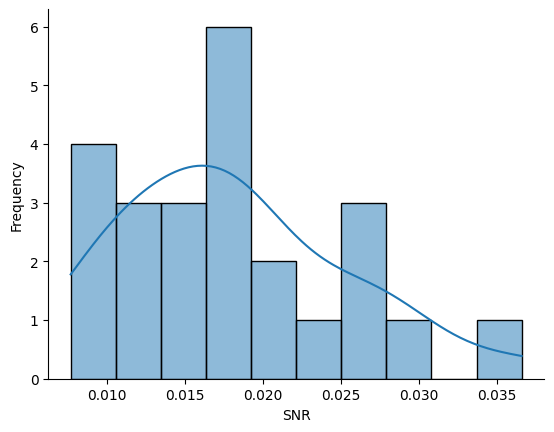

In [8]:
snr_list = [0.0196991187488852, 0.0291119097017132, 0.009868315372056239, 0.02666920728512233, 0.012530722513964174, 0.023969897215134296, 0.026436919129805385, 0.019008834666825788, 0.014048736255142842, 0.018222607813836222, 0.03655696258923394, 0.00945854991438873, 0.017826522554411507, 0.016721016465301754, 0.01134745499645742, 0.027609353003180823, 0.019002938368900588, 0.014779159602009994, 0.019332472019233885, 0.012547128382596882, 0.015449975415808167, 0.017610806336780898, 0.009659853650544005, 0.007693769241799343]
sns.histplot(snr_list, bins=10, kde=True)
plt.xlabel("SNR")
plt.ylabel("Frequency")
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
# save
plt.savefig(f"{save_dir}/single_vs_multi_sim/snr_distribution.pdf", bbox_inches='tight')
plt.show()


In [9]:
results_df, parcellations_single_threshold,parcellations_single_percentage, parcellations_multi = sim.sim_single_vs_multi(
    U_individuals,
    U_individuals_collapsed,
    base_noise=0.04,
    snr_ratios=snr_list,seed=47
)


Best threshold (matched to actual data): 0.093
Best percentile threshold (matched to actual data): 0.800


In [10]:
# check size of true vs predicted for each localizer type
summary = (results_df.groupby("type")[["true_size", "predicted_size"]].mean().reset_index())
print(summary)

                  type  true_size  predicted_size
0           contrast_T    180.402        180.4020
1  contrast_percentage    180.402        180.0000
2                multi    180.402        179.0706


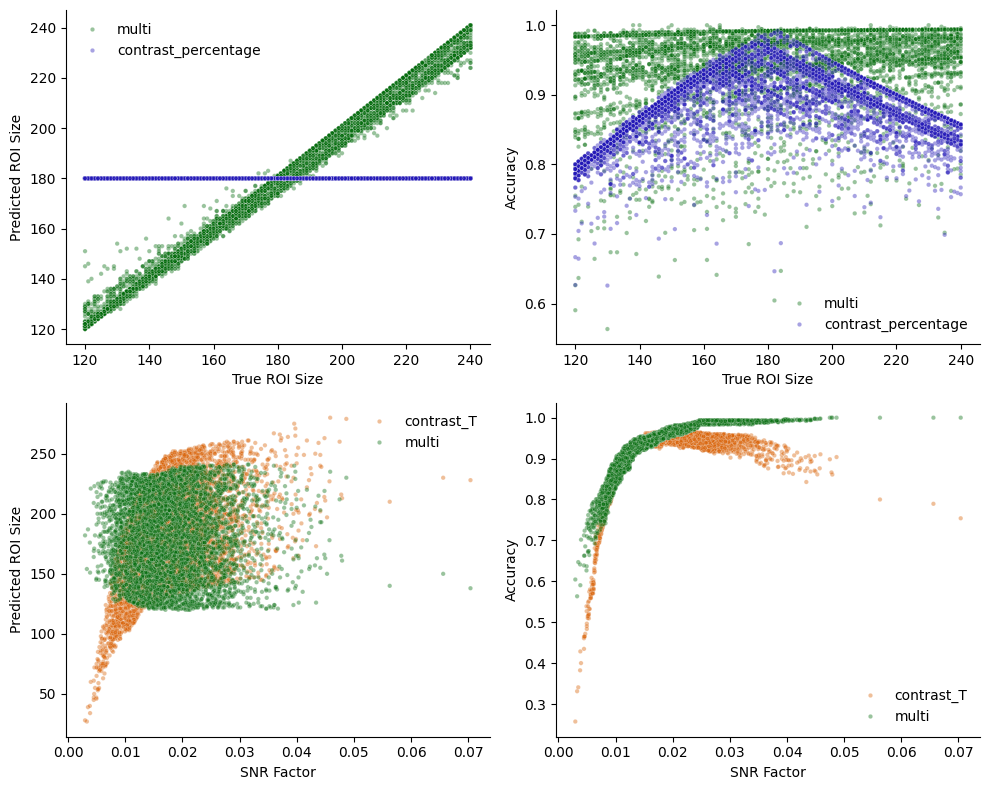

In [ ]:
palette = {
    "multi": "#026b0b",
    "contrast_percentage": "#2318b8",
    "contrast_T": "#d95f02"
}

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# (A) True ROI size vs Predicted ROI size
sns.scatterplot(
    data=results_df[results_df["type"].isin(["contrast_percentage", "multi"])],
    x="true_size", y="predicted_size", hue="type",
    palette=palette, alpha=0.4, s=10, ax=axes[0,0]
)
axes[0,0].set_xlabel("True ROI Size")
axes[0,0].set_ylabel("Predicted ROI Size")

# (B) True ROI size vs Accuracy
sns.scatterplot(
    data=results_df[results_df["type"].isin(["contrast_percentage", "multi"])],
    x="true_size", y="accuracy", hue="type",
    palette=palette, alpha=0.4, s=10, ax=axes[0,1]
)
axes[0,1].set_xlabel("True ROI Size")
axes[0,1].set_ylabel("Accuracy")

# (C) SNR vs Predicted ROI size
sns.scatterplot(
    data=results_df[results_df["type"].isin(["contrast_T", "multi"])],
    x="snr_factor", y="predicted_size", hue="type",
    palette=palette, alpha=0.4, s=10, ax=axes[1,0]
)
axes[1,0].set_xlabel("SNR Factor")
axes[1,0].set_ylabel("Predicted ROI Size")

# (D) SNR vs Accuracy
sns.scatterplot(
    data=results_df[results_df["type"].isin(["contrast_T", "multi"])],
    x="snr_factor", y="accuracy", hue="type",
    palette=palette, alpha=0.4, s=10, ax=axes[1,1]
)
axes[1,1].set_xlabel("SNR Factor")
axes[1,1].set_ylabel("Accuracy")

for ax in axes.flat:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend().set_title("")
    ax.legend().set_frame_on(False)

plt.tight_layout()
plt.show()

# save
fig.savefig(f"{save_dir}/single_vs_multi_sim/full_scatterplots.png",bbox_inches='tight')



In [16]:
palette = {
    "multi": "#026b0b",
    "contrast_percentage": "#2318b8",
    "contrast_T": "#d95f02"
}

# (A) True ROI size vs Predicted ROI size
fig, ax = plt.subplots(figsize=(5, 4))
sns.scatterplot(
    data=results_df[results_df["type"].isin(["contrast_percentage", "multi"])],
    x="true_size", y="predicted_size", hue="type",
    palette=palette, alpha=0.4, s=10, ax=ax
)
ax.set_xlabel("True ROI Size")
ax.set_ylabel("Predicted ROI Size")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend().set_title("")
ax.legend().set_frame_on(False)
fig.tight_layout()
fig.savefig(f"{save_dir}/single_vs_multi_sim/scatter_A_true_vs_pred.pdf", dpi=300, bbox_inches='tight')
plt.close(fig)

# (B) True ROI size vs Accuracy
fig, ax = plt.subplots(figsize=(5, 4))
sns.scatterplot(
    data=results_df[results_df["type"].isin(["contrast_percentage", "multi"])],
    x="true_size", y="accuracy", hue="type",
    palette=palette, alpha=0.4, s=10, ax=ax
)
ax.set_xlabel("True ROI Size")
ax.set_ylabel("Accuracy")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend().set_title("")
ax.legend().set_frame_on(False)
fig.tight_layout()
fig.savefig(f"{save_dir}/single_vs_multi_sim/scatter_B_true_vs_acc.pdf", dpi=300, bbox_inches='tight')
plt.close(fig)

# (C) SNR vs Predicted ROI size
fig, ax = plt.subplots(figsize=(5, 4))
sns.scatterplot(
    data=results_df[results_df["type"].isin(["contrast_T", "multi"])],
    x="snr_factor", y="predicted_size", hue="type",
    palette=palette, alpha=0.4, s=10, ax=ax
)
ax.set_xlabel("SNR Factor")
ax.set_ylabel("Predicted ROI Size")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend().set_title("")
ax.legend().set_frame_on(False)
fig.tight_layout()
fig.savefig(f"{save_dir}/single_vs_multi_sim/scatter_C_snr_vs_pred.pdf", dpi=300, bbox_inches='tight')
plt.close(fig)

# (D) SNR vs Accuracy
fig, ax = plt.subplots(figsize=(5, 4))
sns.scatterplot(
    data=results_df[results_df["type"].isin(["contrast_T", "multi"])],
    x="snr_factor", y="accuracy", hue="type",
    palette=palette, alpha=0.4, s=10, ax=ax
)
ax.set_xlabel("SNR Factor")
ax.set_ylabel("Accuracy")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend().set_title("")
ax.legend().set_frame_on(False)
fig.tight_layout()
fig.savefig(f"{save_dir}/single_vs_multi_sim/scatter_D_snr_vs_acc.pdf", dpi=300, bbox_inches='tight')
plt.close(fig)


# check correlations between SNR factor and predicted size 

In [ ]:

for t in ["contrast_T", "multi"]:
    df = results_df[results_df["type"] == t]
    r, p = pearsonr(df["snr_factor"], df["predicted_size"])
    print(f"{t}: r={r:.3f}, p={p:.3e}")


contrast_T: r=0.500, p=3.871e-315
multi: r=0.017, p=2.161e-01


# plot individuals with high/low SNR and small/large ROIs

Selected individuals:
lowSNR_normSize: subj=1164, SNR=0.0074, size=180.0      
highSNR_normSize: subj=2296, SNR=0.0334, size=180.0     
normSNR_smallROI: subj=1414, SNR=0.0170, size=122.0     
normSNR_largeROI: subj=3122, SNR=0.0171, size=238.0     

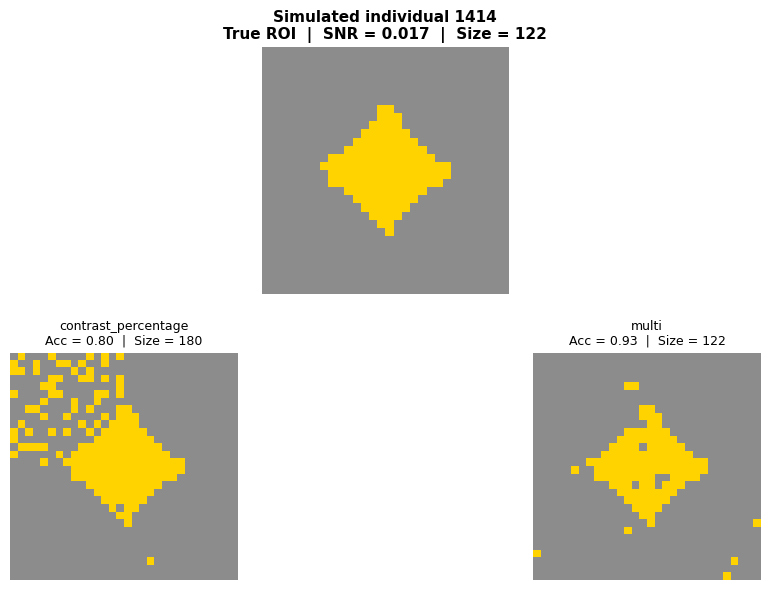

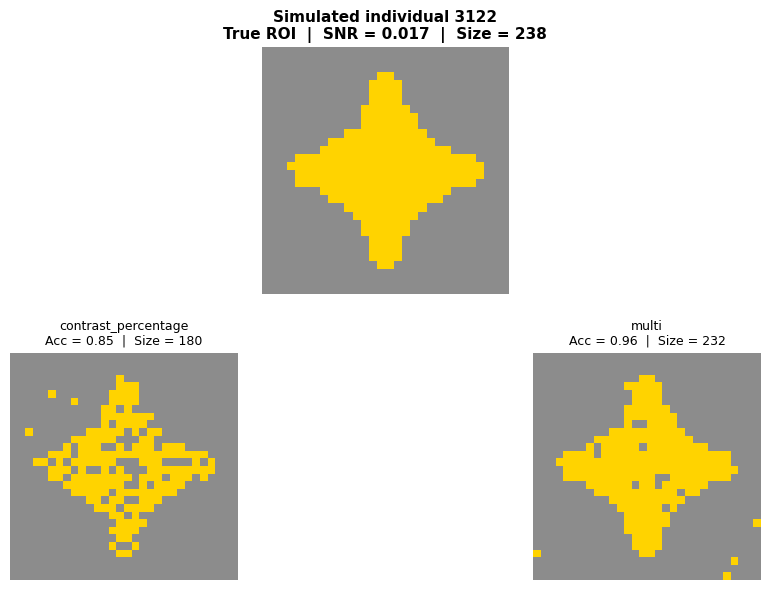

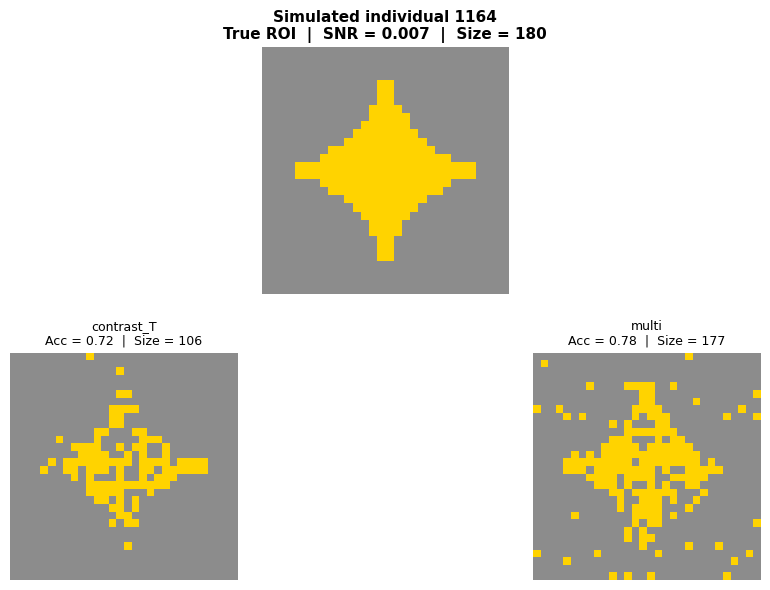

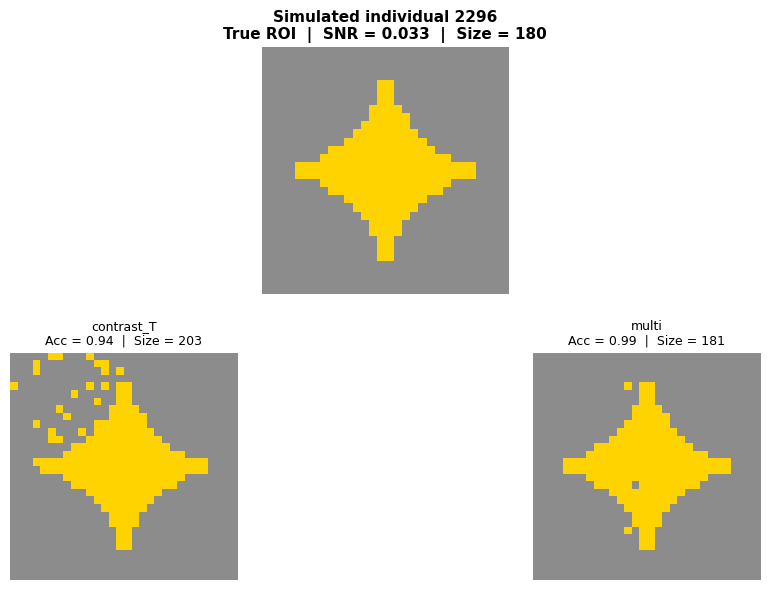

In [ ]:
# Pack parcellations into a dict
parcellations = {
    "contrast_T": parcellations_single_threshold,
    "contrast_percentage": parcellations_single_percentage,
    "multi": parcellations_multi
}

fig = plot.plot_sim_subject_parcellation(
    i=1414,
    U_individuals_collapsed=U_individuals_collapsed,
    parcellations_dict=parcellations,
    results_df=results_df,
    grid_width=grid_width,
    grid_height=grid_height,
    methods=('contrast_percentage', 'multi')
)
# save as pdf
fig.savefig(f"{save_dir}/single_vs_multi/simulated_subject_normSNR_smallsize.pdf", bbox_inches='tight')


fig = plot.plot_sim_subject_parcellation(
    i=3122,
    U_individuals_collapsed=U_individuals_collapsed,
    parcellations_dict=parcellations,
    results_df=results_df,
    grid_width=grid_width,
    grid_height=grid_height,
    methods=('contrast_percentage', 'multi')
)
fig.savefig(f"{save_dir}/single_vs_multi/simulated_subject_normSNR_highsize.pdf", bbox_inches='tight')

fig = plot.plot_sim_subject_parcellation(
    i=1164,
    U_individuals_collapsed=U_individuals_collapsed,
    parcellations_dict=parcellations,
    results_df=results_df,
    grid_width=grid_width,
    grid_height=grid_height,
    methods=('contrast_T', 'multi')
)
fig.savefig(f"{save_dir}/single_vs_multi/simulated_subject_lowSNR_normsize.pdf", bbox_inches='tight')


fig = plot.plot_sim_subject_parcellation(
    i=2296,
    U_individuals_collapsed=U_individuals_collapsed,
    parcellations_dict=parcellations,
    results_df=results_df,
    grid_width=grid_width,
    grid_height=grid_height,
    methods=('contrast_T', 'multi')
)
fig.savefig(f"{save_dir}/single_vs_multi/simulated_subject_highSNR_normsize.pdf", bbox_inches='tight')